## Testing Vectorizing Common Words in Unique Text Columns

Import after dimensionality reduction part of script

In [205]:
import os
os.getcwd()
#os.chdir("/Users/ellawileman/Documents/spring2025/dsci2/dsci2_final_project")

'/Users/ellawileman/Documents/spring2025/dsci2/dsci2_final_project'

In [206]:
import pandas as pd
import numpy as np
from sklearn.feature_extraction.text import TfidfVectorizer
#jobs = pd.read_csv("fake_job_postings.csv")
jobs = pd.read_csv("jobs_clean.csv")

In [207]:
jobs.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 17880 entries, 0 to 17879
Data columns (total 31 columns):
 #   Column                             Non-Null Count  Dtype 
---  ------                             --------------  ----- 
 0   department                         6327 non-null   object
 1   company_profile                    14572 non-null  object
 2   description                        17878 non-null  object
 3   requirements                       15182 non-null  object
 4   benefits                           10660 non-null  object
 5   telecommuting                      17880 non-null  int64 
 6   has_company_logo                   17880 non-null  int64 
 7   has_questions                      17880 non-null  int64 
 8   employment_type                    14409 non-null  object
 9   industry                           12977 non-null  object
 10  function                           11425 non-null  object
 11  fraudulent                         17880 non-null  int64 
 12  Sala

1. vectorize "description" column and get top most frequent words as attributes
2. one-hot encode all other columns
3. stack them so we can train model on vectorized description AND other columns. We can repeat this for other high cardinality string type attributes.

In [208]:
jobs.nunique()

department                             143
company_profile                       1709
description                          14665
requirements                         11898
benefits                              6079
telecommuting                            2
has_company_logo                         2
has_questions                            2
employment_type                          5
industry                                80
function                                37
fraudulent                               2
Salary Given                             2
Grouped_Titles                       10909
Country                                 91
Region                                 325
City                                  2218
special_characters                       2
Bachelor_degree                          2
High school or equivalent                2
Unspecified degree requirement           2
Masters_degree                           2
Associates degree                        2
Certificati

Further grouping job titles: methodology is open to some review -- nothing is final

In [209]:
from sklearn.feature_extraction.text import CountVectorizer
import pandas as pd
from nltk.corpus import stopwords
import string
default_stopwords = set(stopwords.words('english'))
# Assuming 'Grouped_Titles' is the column of interest
grouped_titles = jobs['Grouped_Titles'].fillna('')  # Replace NaN with empty strings
one_letter_words = set(string.ascii_lowercase)  # a, b, c, ..., z

# Combine the default stopwords with one-letter and two-letter words
extended_stopwords = default_stopwords.union(one_letter_words)
extended_stopwords = list(extended_stopwords)


# Preprocess the text
grouped_titles = grouped_titles.str.replace(r'\d+', '', regex=True)  # Remove numbers
grouped_titles = grouped_titles.str.replace(r'\byear olds?\b', '', regex=True, case=False)  # Remove "year olds"
grouped_titles = grouped_titles.str.replace(r'[^a-zA-Z\s]', '', regex=True)  # Remove non-alphabetic characters

# Adjustable thresholds
BIGRAM_THRESHOLD = 200  # Increase the number of top bigrams
UNIGRAM_THRESHOLD = 200  # Increase the number of top unigrams

# Step 1: Extract Bigrams
vectorizer_bigrams = CountVectorizer(ngram_range=(2, 2), stop_words=extended_stopwords, token_pattern=r'\b[a-zA-Z]+\b')
bigrams = vectorizer_bigrams.fit_transform(grouped_titles)

# Get the top bigrams
bigram_counts = bigrams.sum(axis=0)
bigram_frequencies = [(phrase, bigram_counts[0, idx]) for phrase, idx in vectorizer_bigrams.vocabulary_.items()]
bigram_frequencies = sorted(bigram_frequencies, key=lambda x: x[1], reverse=True)
top_bigrams = [phrase for phrase, count in bigram_frequencies[:BIGRAM_THRESHOLD]]

# Step 2: Extract Unigrams
vectorizer_unigrams = CountVectorizer(ngram_range=(1, 1), stop_words=extended_stopwords, token_pattern=r'\b[a-zA-Z]+\b')
unigrams = vectorizer_unigrams.fit_transform(grouped_titles)

# Get the top unigrams
unigram_counts = unigrams.sum(axis=0)
unigram_frequencies = [(word, unigram_counts[0, idx]) for word, idx in vectorizer_unigrams.vocabulary_.items()]
unigram_frequencies = sorted(unigram_frequencies, key=lambda x: x[1], reverse=True)
top_unigrams = [word for word, count in unigram_frequencies[:UNIGRAM_THRESHOLD]]

def map_to_bigram_or_unigram(title):
    # Check for specific bigrams first
    for bigram in top_bigrams:
        if bigram in title.lower():
            return bigram
    # Fallback to generic unigrams
    for unigram in top_unigrams:
        if unigram in title.lower():
            return unigram
    return "Other"


# Step 5: Apply the Mapping
jobs['Mapped_Title'] = grouped_titles.apply(lambda title: map_to_bigram_or_unigram(title))

# Analyze the distribution of groups
group_distribution = jobs['Mapped_Title'].value_counts()
print(group_distribution)

# Display the percentage of "Other"
percent_other = (group_distribution['Other'] / len(jobs)) * 100
print(f"Percentage of 'Other': {percent_other:.2f}%")

# don't want too many titles to be placed into other (loss of detail/info)

Mapped_Title
manager               761
customer service      750
english teacher       721
Other                 696
engineer              628
                     ... 
rails                   1
beauty promotional      1
experience              1
insurance               1
entry clerk             1
Name: count, Length: 323, dtype: int64
Percentage of 'Other': 3.89%


In [210]:
# now want to group very low frequency titles into "Other"
MIN_FREQUENCY = 30  # Set the minimum frequency threshold

# Get the frequency of each label
label_frequencies = jobs['Mapped_Title'].value_counts()

# Identify labels below the threshold
low_frequency_labels = label_frequencies[label_frequencies < MIN_FREQUENCY].index

# Reassign low-frequency labels to "Other"
jobs['Mapped_Title'] = jobs['Mapped_Title'].apply(lambda x: "Other" if x in low_frequency_labels else x)

# Reanalyze the distribution of groups
group_distribution = jobs['Mapped_Title'].value_counts()

# Display the updated percentage of "Other"
percent_other = (group_distribution['Other'] / len(jobs)) * 100
print(f"Updated Percentage of 'Other': {percent_other:.2f}%")

display(group_distribution)

Updated Percentage of 'Other': 16.68%


Mapped_Title
Other                     2982
manager                    761
customer service           750
english teacher            721
engineer                   628
                          ... 
recruitment consultant      30
technical                   30
junior                      30
frontend engineer           30
title closer                30
Name: count, Length: 145, dtype: int64

Replicating logic to drop high-cardinality attributes (but plus description)

In [211]:
# X = jobs["description"]

# getting description, company profile, requirements attributes to tokenize
unique_values = jobs.nunique() 
selected_columns = unique_values[(unique_values <= 145) | (unique_values == 14665) | (unique_values == 1709) | (unique_values == 11898) | (unique_values == 6079)].index

# Create a new DataFrame with selected columns
new_df = jobs[selected_columns]
new_df.columns

Index(['department', 'company_profile', 'description', 'requirements',
       'benefits', 'telecommuting', 'has_company_logo', 'has_questions',
       'employment_type', 'industry', 'function', 'fraudulent', 'Salary Given',
       'Country', 'special_characters', 'Bachelor_degree',
       'High school or equivalent', 'Unspecified degree requirement',
       'Masters_degree', 'Associates degree', 'Certification',
       'Some College Coursework Completed', 'Mid-Senior', 'Entry level',
       'Associate', 'Not Application', 'Director', 'Internship',
       'Mapped_Title'],
      dtype='object')

Vectorize description column and company profile column using TfidfVectorizer (top 100 words)

In [212]:
from sklearn.feature_extraction.text import TfidfVectorizer
from nltk.corpus import stopwords
import nltk
import string

# Replace NaN values in 'description' and 'company_profile' with empty strings
new_df['description'] = new_df['description'].fillna('')
new_df['company_profile'] = new_df['company_profile'].fillna('')
new_df['requirements'] = new_df['requirements'].fillna('')
new_df["benefits"] = new_df["benefits"].fillna('')

# Remove numbers directly from the text columns
new_df['description'] = new_df['description'].str.replace(r'\d+', '', regex=True)
new_df['company_profile'] = new_df['company_profile'].str.replace(r'\d+', '', regex=True)
new_df['requirements'] = new_df['requirements'].str.replace(r'\d+', '', regex=True)
new_df['benefits'] = new_df['benefits'].str.replace(r'\d+', '', regex=True)

# modifying stopwords list to excluse any one or two letter words
nltk.download('stopwords')
# Load default English stopwords
default_stopwords = set(stopwords.words('english'))
one_letter_words = set(string.ascii_lowercase)  # a, b, c, ..., z
two_letter_words = {a + b for a in string.ascii_lowercase for b in string.ascii_lowercase}  # aa, ab, ..., zz
# Combine default stopwords with one- and two-letter words
custom_stopwords = default_stopwords.union(one_letter_words).union(two_letter_words)
# Convert the stopwords set to a list (required by TfidfVectorizer)
custom_stopwords = list(custom_stopwords)

# Initialize TfidfVectorizer
vectorizer_description = TfidfVectorizer(ngram_range=(2, 5), max_features=100, stop_words=custom_stopwords)  # For description
vectorizer_company = TfidfVectorizer(ngram_range=(2, 5), max_features=100, stop_words=custom_stopwords)  # For company_profile
vectorizer_requirements = TfidfVectorizer(ngram_range=(2, 5), max_features=100, stop_words=custom_stopwords)  # For requirements
vectorizer_benefits = TfidfVectorizer(ngram_range=(2, 5), max_features=100, stop_words=custom_stopwords)  # For benefits

# Fit and transform the 'description' column
vectorizer_description.fit(new_df['description'])
new_df['description_vector'] = list(vectorizer_description.transform(new_df['description']).toarray())

# Fit and transform the 'company_profile' column
vectorizer_company.fit(new_df['company_profile'])
new_df['company_profile_vector'] = list(vectorizer_company.transform(new_df['company_profile']).toarray())

# Fit and transform the 'requirements' column
vectorizer_requirements.fit(new_df['requirements'])
new_df['requirements_vector'] = list(vectorizer_requirements.transform(new_df['requirements']).toarray())

# for benefits column
vectorizer_benefits.fit(new_df['benefits'])
new_df['benefits_vector'] = list(vectorizer_benefits.transform(new_df['benefits']).toarray())

# Drop the original text columns if no longer needed
new_df.drop(columns=['description', 'company_profile', 'requirements', 'benefits'], inplace=True)

# Print the selected features for both columns
print("Description Features:", vectorizer_description.get_feature_names_out())
print("Company Profile Features:", vectorizer_company.get_feature_names_out())


/var/folders/yz/btvl331d4g54624wdzgx_2hc0000gn/T/ipykernel_5912/3310682716.py:7: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  new_df['description'] = new_df['description'].fillna('')
/var/folders/yz/btvl331d4g54624wdzgx_2hc0000gn/T/ipykernel_5912/3310682716.py:8: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  new_df['company_profile'] = new_df['company_profile'].fillna('')
/var/folders/yz/btvl331d4g54624wdzgx_2hc0000gn/T/ipykernel_5912/3310682716.py:9: SettingWithCopyWarning: 
A value is trying to be set on

Description Features: ['adkins url_edcbafbeedcdbdeccddacfdf'
 'adkins url_edcbafbeedcdbdeccddacfdf url_dbdfcdbecfcabaeaacbfdeb'
 'apply directly' 'asia usd' 'asia usd monthly' 'asia usd monthly cost'
 'asia usd monthly cost living' 'best practices' 'business development'
 'cardsgabriel adkins' 'cardsgabriel adkins url_edcbafbeedcdbdeccddacfdf'
 'cardsgabriel adkins url_edcbafbeedcdbdeccddacfdf url_dbdfcdbecfcabaeaacbfdeb'
 'click apply' 'communication skills' 'cost living' 'cost living housing'
 'credit cardsgabriel' 'credit cardsgabriel adkins'
 'credit cardsgabriel adkins url_edcbafbeedcdbdeccddacfdf'
 'credit cardsgabriel adkins url_edcbafbeedcdbdeccddacfdf url_dbdfcdbecfcabaeaacbfdeb'
 'customer service' 'day day' 'development team' 'fast growing'
 'fast paced' 'feel free' 'front end' 'full time' 'get paid'
 'get paid love' 'get paid love travel' 'get paid love travel jobs'
 'high quality' 'ideal candidate' 'include limited' 'integral part'
 'job openings' 'jobs asia' 'jobs asia us

In [213]:
print("Requirements Features:", vectorizer_requirements.get_feature_names_out())

Requirements Features: ['ability work' 'able work' 'attention detail' 'bachelor degree'
 'best practices' 'celta teaching' 'celta teaching experience'
 'celta teaching experience preferred'
 'celta teaching experience preferred necessarycanada'
 'communication skills' 'communication skills verbal' 'computer science'
 'customer service' 'customer service related' 'degree computer'
 'degree computer science' 'degree required' 'degree required tefl'
 'degree required tefl tesol' 'degree required tefl tesol celta'
 'development experience' 'diploma equivalent' 'diploma equivalent ged'
 'driver license' 'equivalent ged' 'excellent communication'
 'experience preferred' 'experience preferred necessarycanada'
 'experience preferred necessarycanada passport' 'experience required'
 'experience working' 'experience years' 'fast paced' 'full time'
 'high school' 'high school diploma' 'html css' 'interpersonal skills'
 'least years' 'management skills' 'microsoft office' 'minimum years'
 'minimum 

In [214]:
print("Benefits Features:", vectorizer_benefits.get_feature_names_out())

Benefits Features: ['base salary' 'benefits include' 'benefits including' 'benefits package'
 'benefits package full' 'benefits package full time'
 'benefits package full time employees' 'career prospects'
 'color religion' 'company match' 'company offers' 'compensation package'
 'competitive base' 'competitive benefits' 'competitive compensation'
 'competitive salary' 'comprehensive benefits'
 'comprehensive benefits package' 'comprehensive benefits package full'
 'comprehensive benefits package full time' 'cutting edge'
 'dental insurance' 'dental life' 'dental life disability' 'dental vision'
 'dental vision insurance' 'disability insurance' 'employment paid'
 'employment vacation' 'employment vacation hours year'
 'equal opportunity' 'equal opportunity employer' 'every day'
 'fast growing' 'fast paced' 'full benefits' 'full time'
 'full time employees' 'fully stocked' 'growing company' 'gym membership'
 'hard work' 'health dental' 'health dental vision' 'health insurance'
 'hours m

Data preparation: storing these tokens (most frequent words) with their respective column name

In [215]:
import pandas as pd
import numpy as np
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.preprocessing import OneHotEncoder

# Step 1: Decompose description_vector and company_profile_vector
description_features = vectorizer_description.get_feature_names_out()
company_profile_features = vectorizer_company.get_feature_names_out()
requirements_features = vectorizer_requirements.get_feature_names_out()
benefits_features = vectorizer_benefits.get_feature_names_out()

# Add suffixes to feature names
description_feature_names = [f"description_includes_{feature}" for feature in description_features]
company_profile_feature_names = [f"companyprof_includes_{feature}" for feature in company_profile_features]
requirements_feature_names = [f"requirements_includes_{feature}" for feature in requirements_features]
benefits_feature_names = [f"benefits_includes_{feature}" for feature in benefits_features]


# Convert description_vector and company_profile_vector to DataFrames
description_df = pd.DataFrame(
    np.vstack(new_df['description_vector'].values), 
    columns=description_feature_names
)
company_profile_df = pd.DataFrame(
    np.vstack(new_df['company_profile_vector'].values), 
    columns=company_profile_feature_names
)
requirements_df = pd.DataFrame(
    np.vstack(new_df['requirements_vector'].values), 
    columns=requirements_feature_names
)
benefits_df = pd.DataFrame(
    np.vstack(new_df['benefits_vector'].values), 
    columns=benefits_feature_names
)

# Concatenate the new DataFrames with the original DataFrame
new_df = pd.concat([new_df.reset_index(drop=True), description_df, company_profile_df, requirements_df, benefits_df], axis=1)

# Drop the original vector columns if no longer needed
new_df.drop(columns=['description_vector', 'company_profile_vector', 'requirements_vector', 'benefits_vector'], inplace=True)

# Step 2: One-Hot Encode Categorical Columns
encoder = OneHotEncoder(sparse_output=False)
categorical_columns = new_df.columns.difference(['fraudulent'] + description_feature_names + company_profile_feature_names + requirements_feature_names + benefits_feature_names)
categorical_features = encoder.fit_transform(new_df[categorical_columns])

categorical_feature_names = encoder.get_feature_names_out(categorical_columns)  # Feature names for categorical features
# Combine all feature names into a single list
all_feature_names = np.concatenate([description_feature_names, company_profile_feature_names, requirements_feature_names, benefits_feature_names, categorical_feature_names])

# Combine all features into a single matrix
X = np.hstack([description_df.values, company_profile_df.values, requirements_df.values, benefits_df.values, categorical_features])
y = new_df['fraudulent'].values  # Target variable

# Check the shape of the final feature matrix
print(f"Feature matrix shape: {X.shape}")

Feature matrix shape: (17880, 940)


In [216]:
len(categorical_features)

17880

In [217]:
new_df.columns

Index(['department', 'telecommuting', 'has_company_logo', 'has_questions',
       'employment_type', 'industry', 'function', 'fraudulent', 'Salary Given',
       'Country',
       ...
       'benefits_includes_vacation hours months employment',
       'benefits_includes_vision insurance',
       'benefits_includes_without regard',
       'benefits_includes_without regard race',
       'benefits_includes_work environment', 'benefits_includes_work life',
       'benefits_includes_work life balance',
       'benefits_includes_working environment',
       'benefits_includes_year employment',
       'benefits_includes_year employment paid'],
      dtype='object', length=425)

Extract description_vector as Numpy array, 
one-hot-encode categorical columns
combine encoded features with description_vector
train classifier on this

In [218]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score
from sklearn.preprocessing import OneHotEncoder


One hot encode all other categorical columns:

In [219]:
'''
from sklearn.preprocessing import OneHotEncoder
import numpy as np

# Separate the target column
jobs = new_df
y = jobs['fraudulent'].values
# Select all columns except 'description_vector' and 'fraudulent'
# Step 2: One-Hot Encode Categorical Columns
encoder = OneHotEncoder(sparse_output=False)
categorical_columns = new_df.columns.difference(['fraudulent'] + description_feature_names + company_profile_feature_names)
categorical_features = encoder.fit_transform(new_df[categorical_columns])

# Step 3: Combine All Features
X = np.hstack([new_df[description_feature_names + company_profile_feature_names].values, categorical_features])

# Check the shape of the final feature matrix
print(X.shape)
'''

"\nfrom sklearn.preprocessing import OneHotEncoder\nimport numpy as np\n\n# Separate the target column\njobs = new_df\ny = jobs['fraudulent'].values\n# Select all columns except 'description_vector' and 'fraudulent'\n# Step 2: One-Hot Encode Categorical Columns\nencoder = OneHotEncoder(sparse_output=False)\ncategorical_columns = new_df.columns.difference(['fraudulent'] + description_feature_names + company_profile_feature_names)\ncategorical_features = encoder.fit_transform(new_df[categorical_columns])\n\n# Step 3: Combine All Features\nX = np.hstack([new_df[description_feature_names + company_profile_feature_names].values, categorical_features])\n\n# Check the shape of the final feature matrix\nprint(X.shape)\n"

In [220]:
'''
# One-hot encode the categorical columns
categorical_features = encoder.fit_transform(jobs[categorical_columns])

# Convert description_vector to a 2D NumPy array
description_vectors = np.vstack(jobs['description_vector'].values)
company_profile_vectors = np.vstack(jobs['company_profile_vector'].values)
X = np.hstack([description_vectors, company_profile_vectors, categorical_features])

print(X.shape)  # Check the shape of the combined feature matrix
X
'''

"\n# One-hot encode the categorical columns\ncategorical_features = encoder.fit_transform(jobs[categorical_columns])\n\n# Convert description_vector to a 2D NumPy array\ndescription_vectors = np.vstack(jobs['description_vector'].values)\ncompany_profile_vectors = np.vstack(jobs['company_profile_vector'].values)\nX = np.hstack([description_vectors, company_profile_vectors, categorical_features])\n\nprint(X.shape)  # Check the shape of the combined feature matrix\nX\n"

In [221]:
# After one-hot encoding:
len(X[0])
# there are 595 attributes!
# 395 attributes from one-hot encoding categorical predictors, and 100 from each of the text features

940

Random forest classifier

In [222]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report

# Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Train a Random Forest model
model = RandomForestClassifier(random_state=42)
model.fit(X_train, y_train)
feature_importances = model.feature_importances_

# Make predictions and evaluate the model
y_pred = model.predict(X_test)
accuracy = accuracy_score(y_test, y_pred)
print(f"Accuracy: {accuracy:.4f}")
print(classification_report(y_test, y_pred))

# Sort features by importance
sorted_indices = np.argsort(feature_importances)[::-1]  # Indices of features sorted by importance (descending)
sorted_features = [(all_feature_names[i], feature_importances[i]) for i in sorted_indices]

# Print the top 10 most important features
print("Top 10 Most Important Features:")
for feature, importance in sorted_features[:10]:
    print(f"{feature}: {importance:.4f}")

# feature importances sum up to 1

Accuracy: 0.9813
              precision    recall  f1-score   support

           0       0.98      1.00      0.99      3395
           1       0.97      0.65      0.78       181

    accuracy                           0.98      3576
   macro avg       0.97      0.83      0.88      3576
weighted avg       0.98      0.98      0.98      3576

Top 10 Most Important Features:
has_company_logo_1: 0.0342
has_company_logo_0: 0.0320
Mapped_Title_data entry: 0.0307
industry_Oil & Energy: 0.0227
description_includes_per week: 0.0124
description_includes_get paid: 0.0121
function_Administrative: 0.0119
has_questions_0: 0.0116
description_includes_part time: 0.0114
Country_US: 0.0107


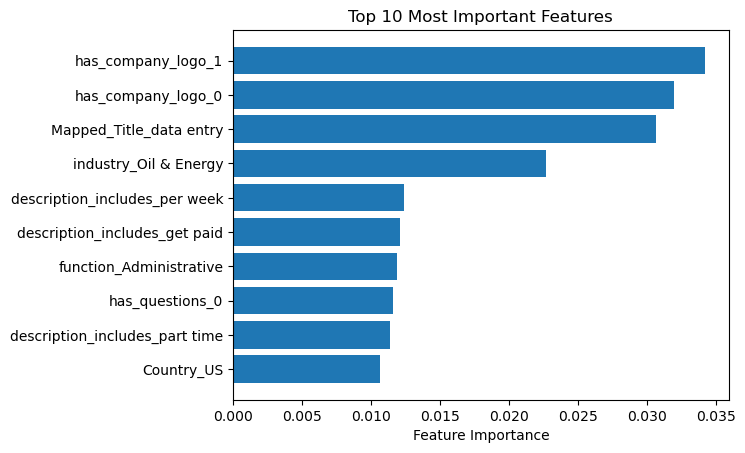

In [223]:
import matplotlib.pyplot as plt

# Plot feature importances
sorted_indices = np.argsort(feature_importances)[::-1]
top_features = sorted_indices[:10]  # Top 10 features
plt.barh(range(10), feature_importances[top_features])
plt.yticks(range(10), [all_feature_names[i] for i in top_features])
plt.xlabel("Feature Importance")
plt.title("Top 10 Most Important Features")
plt.gca().invert_yaxis()
plt.show()

# we expect that feature importance will be low! 

In [224]:
# Smote LR Model
from imblearn.over_sampling import SMOTE
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report
smote = SMOTE(sampling_strategy='auto', random_state=42)  # auto balances the classes
X_train_smote, y_train_smote = smote.fit_resample(X_train, y_train)
model_smote = LogisticRegression(max_iter=1000, class_weight='balanced')
model_smote.fit(X_train_smote, y_train_smote)
y_pred_smote = model_smote.predict(X_test)
print(classification_report(y_test, y_pred_smote))

              precision    recall  f1-score   support

           0       0.99      0.95      0.97      3395
           1       0.46      0.86      0.60       181

    accuracy                           0.94      3576
   macro avg       0.73      0.90      0.78      3576
weighted avg       0.97      0.94      0.95      3576



Small improvement in metrics from version where all these variables are dropped. May see even better model performance with other variable-length string attributes.

We can repeat this methodology with other unique text columns like company description, requirements, benefits. Can also use digram, bigrams, etc. to get most common phrases

Maybe we can continue to group titles more by establishing some hierarchy, same with locations/region

Can we group these vectorized words at all? Try a different type of vectorizer that puts nearby words next to each other numerically (maybe an "includes" function would also be good for groupings rather than having to do all manual mappings)